Импорты:

In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, roc_curve
)

np.random.seed(42)

In [2]:
!pip install catboost vowpalwabbit scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 10.4 MB/s eta 0:00:00


Подготовка признаков и разбиение данных на train / val / test:

In [14]:
name_variants = {
    "Общий анализ крови": [
        "Клинический анализ крови", "ОАК", "Общий ан. крови",
        "Анализ крови общий", "Гемограмма",
        "CBC", "Клинический ан. крови", "Развёрнутый анализ крови"],
    "Гемоглобин": [
        "Гемоглобин (HGB)", "HGB", "Определение гемоглобина",
        "Гемоглобин в крови", "Haemoglobin", "Hb"],
    "АЛТ": [
        "Аланинаминотрансфераза", "АлАТ", "ALT",
        "Аланинаминотрансфераза (АЛТ)",
        "Аланин-аминотрансфераза", "Трансаминаза АЛТ"],
    "АСТ": [
        "Аспартатаминотрансфераза", "АсАТ", "AST",
        "Аспартатаминотрансфераза (АСТ)",
        "Аспартат-аминотрансфераза", "Трансаминаза АСТ"],
    "Креатинин": [
        "Креатинин в крови", "Creatinine", "Креатинин сыворотки",
        "Определение креатинина", "Cr", "Креатинин (кровь)"],
    "ТТГ": [
        "Тиреотропный гормон", "TSH", "Тиреотропин",
        "ТТГ (тиреотропный гормон)", "Гормон ТТГ",
        "Тиреотропный гормон (ТТГ)"],
    "Глюкоза": [
        "Глюкоза в крови", "Сахар крови", "Glucose",
        "Определение глюкозы", "Глюкоза (кровь)",
        "Сахар в крови", "Кровь на сахар"],
    "Ферритин": [
        "Ферритин в крови", "Ferritin", "Определение ферритина",
        "Ферритин сыворотки", "Ферритин (кровь)"],
    "IgE общий": [
        "Иммуноглобулин E общий", "Total IgE", "Общий IgE",
        "Иммуноглобулин Е", "IgE", "Иммуноглобулин E"],
    "АЧТВ": [
        "Активированное частичное тромбопластиновое время", "APTT",
        "АЧТВ (коагулограмма)", "Частичное тромбопластиновое время",
        "АПТВ", "Активированное ЧТВ"],
    "Билирубин общий": [
        "Билирубин", "Total Bilirubin", "Общий билирубин",
        "Билирубин общ.", "Определение билирубина",
        "Билирубин суммарный", "Bil общий"],
    "Холестерин": [
        "Холестерин общий", "Cholesterol", "Холестерол",
        "Общий холестерол", "Холестерин (кровь)",
        "Липидный профиль — холестерин", "CHOL"],
    "Мочевина": [
        "Мочевина в крови", "Urea", "Карбамид",
        "Определение мочевины", "Мочевина (сыворотка)",
        "BUN", "Мочевина сыворотки"],
    "Тромбоциты": [
        "Тромбоциты (PLT)", "PLT", "Platelet count",
        "Число тромбоцитов", "Тромбоциты в крови"],
    "Лейкоциты": [
        "Лейкоциты (WBC)", "WBC", "White blood cells",
        "Число лейкоцитов", "Лейкоциты в крови",
        "Лейкоцитарная формула (общее)"],
    "Витамин D": [
        "Витамин D (25-OH)", "25-OH витамин D", "25(OH)D",
        "Витамин Д", "Кальцидиол", "25-гидроксивитамин D",
        "Vitamin D"],
    "Протромбиновое время": [
        "ПТВ", "PT", "Prothrombin time",
        "Протромбин по Квику", "МНО + протромбиновое время",
        "ПВ (протромбиновое время)"],
    "Фибриноген": [
        "Фибриноген в плазме", "Fibrinogen", "Определение фибриногена",
        "Фибриноген (коагулограмма)", "Фибр."],
    "Кортизол": [
        "Кортизол в крови", "Cortisol", "Определение кортизола",
        "Кортизол (сыворотка)", "Гормон кортизол"],
    "Т4 свободный": [
        "Тироксин свободный", "Free T4", "FT4",
        "Т4 св.", "Свободный тироксин",
        "Тироксин св. (FT4)"],
}

canonical_names = list(name_variants.keys())

def levenshtein_ratio(s1, s2):
    # Нормированное сходство по Левенштейну (0..1, 1 = идентичны)
    s1, s2 = s1.lower(), s2.lower()
    if s1 == s2:
        return 1.0
    len1, len2 = len(s1), len(s2)
    matrix = [[0] * (len2 + 1) for _ in range(len1 + 1)]
    for i in range(len1 + 1):
        matrix[i][0] = i
    for j in range(len2 + 1):
        matrix[0][j] = j
    for i in range(1, len1 + 1):
        for j in range(1, len2 + 1):
            cost = 0 if s1[i-1] == s2[j-1] else 1
            matrix[i][j] = min(
                matrix[i-1][j] + 1,
                matrix[i][j-1] + 1,
                matrix[i-1][j-1] + cost
            )
    max_len = max(len1, len2)
    return 1.0 - matrix[len1][len2] / max_len if max_len > 0 else 1.0

def common_word_ratio(s1, s2):
    # Подсчет доли общих слов
    w1 = set(s1.lower().split())
    w2 = set(s2.lower().split())
    if not w1 or not w2:
        return 0.0
    return len(w1 & w2) / max(len(w1), len(w2))

def len_diff_ratio(s1, s2):
    # Относительная разница по длине
    l1, l2 = len(s1), len(s2)
    return abs(l1 - l2) / max(l1, l2) if max(l1, l2) > 0 else 0.0

# Сначала собираем пары одного и того же исследования (match)
rows = []
for canon, variants in name_variants.items():
    all_names = [canon] + variants
    for i in range(len(all_names)):
        for j in range(i + 1, len(all_names)):
            rows.append({
                "name_a": all_names[i],
                "name_b": all_names[j],
                "label": 1
            })

# Потом добавляем пары разных исследований (non-match)
n_positive = len(rows)
neg_rows = []
all_flat = [(canon, v) for canon, variants in name_variants.items()
            for v in [canon] + variants]

np.random.seed(42)
while len(neg_rows) < n_positive * 3:
    idx_a = np.random.randint(len(all_flat))
    idx_b = np.random.randint(len(all_flat))
    canon_a, name_a = all_flat[idx_a]
    canon_b, name_b = all_flat[idx_b]
    if canon_a != canon_b:
        neg_rows.append({
            "name_a": name_a,
            "name_b": name_b,
            "label": 0
        })

rows.extend(neg_rows)
df_match = pd.DataFrame(rows)

# Считаем признаки для каждой пары
df_match["lev_ratio"] = df_match.apply(
    lambda r: levenshtein_ratio(r["name_a"], r["name_b"]), axis=1)
df_match["word_ratio"] = df_match.apply(
    lambda r: common_word_ratio(r["name_a"], r["name_b"]), axis=1)
df_match["len_diff"] = df_match.apply(
    lambda r: len_diff_ratio(r["name_a"], r["name_b"]), axis=1)
df_match["len_a"] = df_match["name_a"].str.len()
df_match["len_b"] = df_match["name_b"].str.len()

print(f"Размер датасета: {df_match.shape}")
print(f"Баланс классов:")
print(df_match["label"].value_counts(normalize=True).to_string())
print(f"Примеры:")
print(df_match[["name_a", "name_b", "lev_ratio", "word_ratio", "label"]].head(6).to_string())

Размер датасета: (1784, 8)
Баланс классов:
label
0    0.75
1    0.25
Примеры:
               name_a                    name_b  lev_ratio  word_ratio  label
0  Общий анализ крови  Клинический анализ крови   0.625000    0.666667      1
1  Общий анализ крови                       ОАК   0.166667    0.000000      1
2  Общий анализ крови           Общий ан. крови   0.777778    0.666667      1
3  Общий анализ крови        Анализ крови общий   0.333333    1.000000      1
4  Общий анализ крови                Гемограмма   0.055556    0.000000      1
5  Общий анализ крови                       CBC   0.000000    0.000000      1


In [15]:
FEATURES = ["lev_ratio", "word_ratio", "len_diff", "len_a", "len_b"]

X = df_match[FEATURES]
y = df_match["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 1141, Val: 286, Test: 357


EDA — распределение признаков lev_ratio и word_ratio по классам:

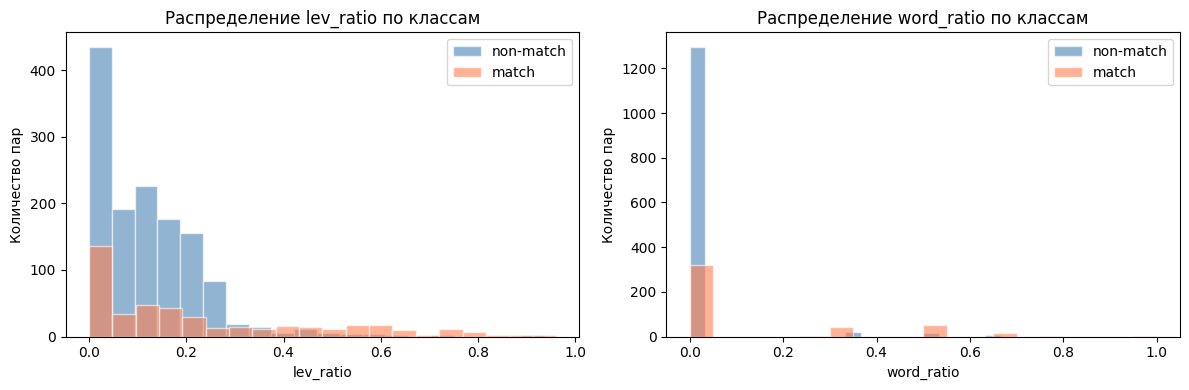

                   name_a                     name_b  lev_ratio  word_ratio  len_diff  label
1373                Фибр.                  Общий IgE   0.111111    0.000000  0.444444      0
1080      Общий ан. крови                        PLT   0.000000    0.000000  0.800000      0
1348                  HGB          Креатинин в крови   0.000000    0.000000  0.823529      0
289      Мочевина в крови                       Urea   0.000000    0.000000  0.750000      1
990    Гемоглобин в крови          Лейкоциты в крови   0.555556    0.666667  0.055556      0
1555      Лейкоциты (WBC)  ТТГ (тиреотропный гормон)   0.200000    0.000000  0.400000      0
1251   Тироксин св. (FT4)   Аспартатаминотрансфераза   0.125000    0.000000  0.250000      0
584       Глюкоза (кровь)    Определение гемоглобина   0.086957    0.000000  0.347826      0
1179          Сахар крови                  Креатинин   0.090909    0.000000  0.181818      0
778   Фибриноген в плазме  Тиреотропный гормон (ТТГ)   0.160000    0.0

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Распределение lev_ratio отдельно по классов
for label, color, name in [(0, "steelblue", "non-match"),
                             (1, "coral", "match")]:
    df_match[df_match["label"]==label]["lev_ratio"].plot(
        kind="hist", bins=20, ax=axes[0], alpha=0.6,
        color=color, label=name, edgecolor="white"
    )
axes[0].set_title("Распределение lev_ratio по классам")
axes[0].set_xlabel("lev_ratio")
axes[0].set_ylabel("Количество пар")
axes[0].legend()

# То же самое для word_ratio
for label, color, name in [(0, "steelblue", "non-match"),
                             (1, "coral", "match")]:
    df_match[df_match["label"]==label]["word_ratio"].plot(
        kind="hist", bins=20, ax=axes[1], alpha=0.6,
        color=color, label=name, edgecolor="white"
    )
axes[1].set_title("Распределение word_ratio по классам")
axes[1].set_xlabel("word_ratio")
axes[1].set_ylabel("Количество пар")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_match.png", dpi=150)
plt.show()

# 10 случайных строк
print(df_match[["name_a","name_b","lev_ratio","word_ratio","len_diff","label"]]
      .sample(10, random_state=42).to_string())

Обучение модели CatBoost:

In [18]:
from catboost import CatBoostClassifier, Pool

train_pool = Pool(X_train, y_train)
val_pool   = Pool(X_val,   y_val)
test_pool  = Pool(X_test,  y_test)

cb_model = CatBoostClassifier(
    iterations=300, depth=4, learning_rate=0.05,
    loss_function="Logloss", eval_metric="AUC",
    random_seed=42, verbose=100,
)

start_cb = time.time()
cb_model.fit(train_pool, eval_set=val_pool, use_best_model=True)
time_cb = time.time() - start_cb

cb_proba = cb_model.predict_proba(X_test)[:, 1]
cb_pred  = cb_model.predict(X_test)

0:	test: 0.6349299	best: 0.6349299 (0)	total: 4ms	remaining: 1.19s
100:	test: 0.7742407	best: 0.7763175 (91)	total: 83.1ms	remaining: 164ms
200:	test: 0.7981244	best: 0.7986436 (198)	total: 159ms	remaining: 78.5ms
299:	test: 0.8014992	best: 0.8042900 (248)	total: 238ms	remaining: 0us

bestTest = 0.8042899792
bestIteration = 248

Shrink model to first 249 iterations.


In [19]:
print("Результаты по CatBoost")
print(f"AUC:       {roc_auc_score(y_test, cb_proba):.4f}")
print(f"F1:        {f1_score(y_test, cb_pred):.4f}")
print(f"Precision: {precision_score(y_test, cb_pred):.4f}")
print(f"Recall:    {recall_score(y_test, cb_pred):.4f}")
print(f"Время:     {time_cb:.2f} с")

Результаты по CatBoost
AUC:       0.7775
F1:        0.5816
Precision: 0.7885
Recall:    0.4607
Время:     0.31 с


Важность признаков CatBoost:

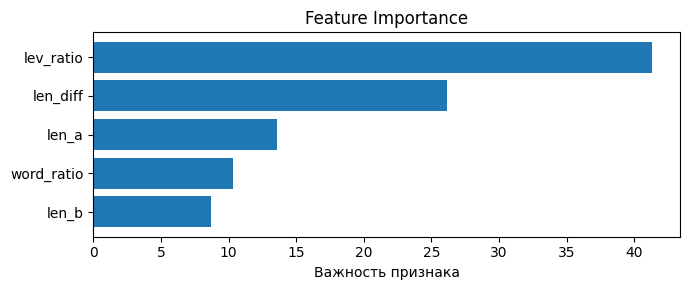

In [20]:
feat_imp = cb_model.get_feature_importance(train_pool)
plt.figure(figsize=(7, 3))
sorted_idx = np.argsort(feat_imp)
plt.barh(X_train.columns[sorted_idx], feat_imp[sorted_idx])
plt.xlabel("Важность признака")
plt.title("Feature Importance")
plt.tight_layout()
plt.savefig("catboost_fi_matching.png", dpi=150)
plt.show()

Обучение модели Vowpal Wabbit:

In [21]:
import vowpalwabbit
import scipy.special

def to_vw_match(row, label):
    lbl = 1 if label == 1 else -1
    feats = (f"lev:{row['lev_ratio']:.4f} "
             f"word:{row['word_ratio']:.4f} "
             f"ldiff:{row['len_diff']:.4f} "
             f"la:{row['len_a']} lb:{row['len_b']}")
    return f"{lbl} |num {feats}"

vw = vowpalwabbit.Workspace(
    "--loss_function logistic --bit_precision 18 "
    "--l2 1e-6 --passes 5 --cache_file /tmp/vw_match.tmp --quiet"
)

start_vw = time.time()
for idx in X_train.index:
    vw.learn(to_vw_match(X_train.loc[idx], y_train[idx]))
time_vw = time.time() - start_vw

vw_raw = [vw.predict(to_vw_match(X_test.loc[idx], y_test[idx]))
          for idx in X_test.index]
vw.finish()

vw_proba = scipy.special.expit(np.array(vw_raw))
vw_pred  = (vw_proba >= 0.5).astype(int)

In [22]:
print("Результаты VW")
print(f"AUC:       {roc_auc_score(y_test, vw_proba):.4f}")
print(f"F1:        {f1_score(y_test, vw_pred):.4f}")
print(f"Precision: {precision_score(y_test, vw_pred):.4f}")
print(f"Recall:    {recall_score(y_test, vw_pred):.4f}")
print(f"Время:     {time_vw:.2f} с")

Результаты VW
AUC:       0.7126
F1:        0.4844
Precision: 0.7949
Recall:    0.3483
Время:     0.12 с


Сводная таблица результатов:

In [23]:
results = pd.DataFrame({
    "Метрика": ["AUC", "F1", "Precision", "Recall", "Время (с)"],
    "CatBoost": [
        roc_auc_score(y_test, cb_proba), f1_score(y_test, cb_pred),
        precision_score(y_test, cb_pred), recall_score(y_test, cb_pred), time_cb],
    "Vowpal Wabbit": [
        roc_auc_score(y_test, vw_proba), f1_score(y_test, vw_pred),
        precision_score(y_test, vw_pred), recall_score(y_test, vw_pred), time_vw],
})
print("Сводная таблица")
print(results.to_string(index=False))

Сводная таблица
  Метрика  CatBoost  Vowpal Wabbit
      AUC  0.777524       0.712624
       F1  0.581560       0.484375
Precision  0.788462       0.794872
   Recall  0.460674       0.348315
Время (с)  0.307573       0.118912
